# Analisis Bag of Words (BoW) & Regex — Aplikasi Jenius
## Alur Analisis
1. Instalasi & Import Library
2. Load Dataset
3. Preprocessing (Tokenisasi, Stopword, Stemming)
4. **Bag of Words — Matrix 50 Kata**
5. **BoW Positif vs Negatif**
6. **Analisis Regex — Insight Review**
7. Visualisasi & Kesimpulan

## 1. Instalasi & Import Library

In [1]:
!pip install google_play_scraper
!pip install PySastrawi

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.6/210.6 kB 3.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from collections import Counter

# NLP
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Sklearn untuk BoW
from sklearn.feature_extraction.text import CountVectorizer

# Download resource NLTK
nltk.download('punkt',    quiet=True)
nltk.download('punkt_tab',quiet=True)
nltk.download('stopwords',quiet=True)

# Konfigurasi tampilan
pd.set_option('display.max_colwidth', 200)
pd.set_option('display.max_columns', 20)

available_styles = matplotlib.style.available
if 'seaborn-v0_8' in available_styles:
    plt.style.use('seaborn-v0_8')
elif 'seaborn' in available_styles:
    plt.style.use('seaborn')
else:
    plt.style.use('ggplot')

plt.rcParams['font.family'] = 'sans-serif'
print('✅ Library berhasil diimport!')

✅ Library berhasil diimport!


---
## 2. 📂 Load Dataset

Dataset dimuat dari Google Drive menggunakan file hasil scraping sebelumnya.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Load dataset mentah hasil scraping
file_path = '/content/drive/My Drive/PBA/rawdata_jenius_id.csv'

try:
    df = pd.read_csv(file_path, low_memory=False)
    print(f'✅ Dataset berhasil dimuat: {len(df):,} baris')
    display(df.head())
except FileNotFoundError:
    print(f'❌ File tidak ditemukan di: {file_path}')
    df = pd.DataFrame()

✅ Dataset berhasil dimuat: 101,151 baris


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,c4fff659-dc8d-4449-92bd-c31e47cce376,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"payah udah cape"" isi data , login suruh isi data lgi . payah dah.",1,0,4.66.1,2026-03-23 09:31:49,"Mohon maaf atas ketidaknyamanan yang kamu alami ya Irfan. Agar dapat dibantu pengecekan lebih lanjut, mohon kesediaan kamu menghubungi SMBCI Care 1500365 ya.",2026-03-23 09:32:47,4.66.1
1,cbfc7f4a-d5f6-48ef-a6f6-2a30ea8e159d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,mohon bantu saya tidak pernah mengajukan pinjaman di aplikasi ini kenapa saya laporan di bi checking cacat Krn aplikasi ini,1,0,4.66.1,2026-03-23 07:25:07,"Hi Sarwedi Silalahi. Mohon maaf atas ketidaknyamanan yang kamu alami. Untuk dibantu pengecekan, mohon kesediaannya kamu dapat menghubungi SMBCI Care melalui telepon di 1500365 atau live chat di da...",2026-03-23 07:32:36,4.66.1
2,163b3f92-772b-41d5-9c89-2d083ed3a355,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,mobile banking paling berat dan lambat yang pernah saya pakai. Tolong diupgrade.,1,0,4.66.1,2026-03-22 23:24:37,"Hi Kusnadi. Mohon maaf atas ketidaknyamanannya. Pastikan koneksi internet dalam keadaan stabil/menggunakan jaringan lain, aplikasi Jenius versi terbaru dan melakukan clear cache. Hal ini menjadi p...",2026-03-22 23:31:12,4.66.1
3,b0eb2070-29d3-4f1d-b525-b2ecc70d0bda,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"tolong perbaiki sistemnya ya, kita sudah berusaha untuk selalu tepat waktu namun sistem selalu membaca terlambat, dan akhirnya terbaca kredibilitas kita kurang, yang mengakibatnya penurunan limit ...",1,0,NaN,2026-03-22 13:33:56,"Hai Andhy Hutomo. Terima kasih atas ulasan yang kamu berikan kepada Jenius. Mohon maaf atas ketidaknyamanan yang kamu alami, informasi yang kamu sampaikan menjadi perhatian dan masukan bagi kami u...",2026-03-22 13:35:34,NaN
4,e265485e-090f-4b1c-9a0b-6df7bdadebfd,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"saya ingin unlink device, tapi sangat sulit. sudah menghubungi lewat email, sudah telpon tapi memakan pulsa, tapi saya sudah beli paket telpon, tidak bisa ditelpon jika menggunakan angka 021.",1,0,4.66.1,2026-03-22 11:17:12,Hi Kak. Mohon maaf atas ketidaknyamanan yang dialami. Jika melalui layanan e-mail Jenius-Help@smbci.com untuk pengajuan unlink device kamu dapat sampaikan ingin dibantu Unlink Device dan informasi...,2026-03-22 11:19:39,4.66.1


In [5]:
# Ringkasan struktur dataset
df.info()
print('\nDistribusi skor ulasan:')
print(df['score'].value_counts().sort_index())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101151 entries, 0 to 101150
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   reviewId              101151 non-null  object
 1   userName              101151 non-null  object
 2   userImage             101151 non-null  object
 3   content               101147 non-null  object
 4   score                 101151 non-null  int64 
 5   thumbsUpCount         101151 non-null  int64 
 6   reviewCreatedVersion  69106 non-null   object
 7   at                    101151 non-null  object
 8   replyContent          29697 non-null   object
 9   repliedAt             29697 non-null   object
 10  appVersion            69106 non-null   object
dtypes: int64(2), object(9)
memory usage: 8.5+ MB

Distribusi skor ulasan:
score
1    20194
2     3863
3     4971
4     4092
5    68031
Name: count, dtype: int64


In [6]:
# Seleksi kolom yang dibutuhkan & tangani missing values
df = df[['content', 'score', 'at']].copy()
df = df.dropna(subset=['content'])
df['content'] = df['content'].astype(str)

# Tambahkan label sentimen berdasarkan rating
df['label'] = df['score'].apply(
    lambda x: 'Positif' if x >= 4 else ('Netral' if x == 3 else 'Negatif')
)

print(f'\nJumlah data setelah seleksi: {len(df):,}')
print('\nDistribusi label sentimen:')
print(df['label'].value_counts())
display(df.head())


Jumlah data setelah seleksi: 101,147

Distribusi label sentimen:
label
Positif    72121
Negatif    24056
Netral      4970
Name: count, dtype: int64


,content,score,at,label
0,"payah udah cape"" isi data , login suruh isi data lgi . payah dah.",1,2026-03-23 09:31:49,Negatif
1,mohon bantu saya tidak pernah mengajukan pinjaman di aplikasi ini kenapa saya laporan di bi checking cacat Krn aplikasi ini,1,2026-03-23 07:25:07,Negatif
2,mobile banking paling berat dan lambat yang pernah saya pakai. Tolong diupgrade.,1,2026-03-22 23:24:37,Negatif
3,"tolong perbaiki sistemnya ya, kita sudah berusaha untuk selalu tepat waktu namun sistem selalu membaca terlambat, dan akhirnya terbaca kredibilitas kita kurang, yang mengakibatnya penurunan limit ...",1,2026-03-22 13:33:56,Negatif
4,"saya ingin unlink device, tapi sangat sulit. sudah menghubungi lewat email, sudah telpon tapi memakan pulsa, tapi saya sudah beli paket telpon, tidak bisa ditelpon jika menggunakan angka 021.",1,2026-03-22 11:17:12,Negatif


## 3. Preprocessing Teks

Tahap pra-pemrosesan dilakukan secara bertahap mengikuti pipeline standar NLP untuk bahasa Indonesia:
1. Lowercasing
2. Pembersihan karakter tidak relevan
3. Tokenisasi
4. Normalisasi slang
5. Stopword removal (Sastrawi)
6. Stemming (Sastrawi)

In [26]:
# Inisialisasi tools
factory_stop   = StopWordRemoverFactory()
factory_stem   = StemmerFactory()
sastrawi_stop  = set(factory_stop.get_stop_words())
sastrawi_stem  = factory_stem.create_stemmer()

# Kata negasi yang tetap dipertahankan
kata_penting = {'tidak', 'bukan', 'belum', 'jangan', 'tanpa', 'kurang', 'susah', 'sulit'}

# Kamus normalisasi slang Jenius
kamus_slang = {
    'ga':'tidak','gak':'tidak','gk':'tidak','ngga':'tidak','nggak':'tidak',
    'gaada':'tidak ada','gabisa':'tidak bisa','gamau':'tidak mau',
    'yg':'yang','udh':'sudah','udah':'sudah','tp':'tapi','kalo':'kalau',
    'klo':'kalau','jd':'jadi','krn':'karena','utk':'untuk','jg':'juga',
    'dr':'dari','dgn':'dengan','aja':'saja','bgt':'sekali','banget':'sekali',
    'sy':'saya','gue':'saya','gw':'saya','nih':'ini','tuh':'itu',
    'apk':'aplikasi','hp':'handphone','pake':'pakai','tf':'transfer',
    'rek':'rekening','cs':'layanan pelanggan','verif':'verifikasi',
    'topup':'isi saldo','rb':'ribu','lemot':'lambat','eror':'error',
    'ribet':'rumit','nyesel':'menyesal','lelet':'lambat',
}

# Custom stopwords domain Jenius
# Tambahkan kata-kata noise ini ke custom_stop
custom_stop = [
    # Domain aplikasi & banking
    'aplikasi', 'jenius', 'bank', 'btpn', 'fitur', 'akun', 'rekening',
    'kartu', 'login', 'call', 'perban', 'aktivasinya', 'wallet', 'card',
    'debit', 'transfer', 'transaksi', 'saldo', 'uang', 'bayar', 'layan',
    'tabung', 'banking', 'mobile', 'digital', 'online',

    # Kata netral / tidak bermakna untuk sentimen
    'tidak', 'tolong', 'bantu', 'pakai', 'coba', 'kasih', 'guna',
    'download', 'top', 'daftar', 'buka', 'data', 'pokok', 'sesal',

    # Nama brand (bukan sentimen)
    'netflix', 'spotify', 'video',

    # Kata seru & kata ganti
    'oke', 'ok', 'ya', 'yah', 'wah', 'deh', 'dong', 'sih',
    'nih', 'tuh', 'aja', 'lagi', 'nya', 'si', 'pak', 'bu', 'mas', 'kak',

    # Simbol & angka
    '&', '.', ',', '-', '!', '?', '1', '2', '3', '4', '5', 'amp',
]

# Gabungkan stopwords (dikurangi kata penting)
stopwords_gabungan = (sastrawi_stop - kata_penting) | set(custom_stop)

print(f'Total stopwords aktif: {len(stopwords_gabungan)}')

Total stopwords aktif: 869


In [27]:
# Pipeline preprocessing
def preprocessing_lengkap(teks):
    # 1. Lowercase
    teks = teks.lower()
    # 2. Hapus URL, mention, angka, simbol
    teks = re.sub(r'http\S+|www\S+', '', teks)
    teks = re.sub(r'@\w+|#\w+', '', teks)
    teks = re.sub(r'[^a-z\s]', ' ', teks)
    teks = re.sub(r'\s+', ' ', teks).strip()
    # 3. Tokenisasi
    tokens = word_tokenize(teks)
    # 4. Normalisasi slang
    tokens = [kamus_slang.get(t, t) for t in tokens]
    # Tokenisasi ulang setelah normalisasi
    tokens = ' '.join(tokens).split()
    # 5. Stopword removal
    tokens = [t for t in tokens if t not in stopwords_gabungan and len(t) > 2]
    # 6. Stemming
    kalimat = ' '.join(tokens)
    hasil_stem = sastrawi_stem.stem(kalimat)
    tokens_final = hasil_stem.split()
    return tokens_final

def teks_bersih(teks):
    return ' '.join(preprocessing_lengkap(teks))

df['tokens']        = df['content'].apply(preprocessing_lengkap)
df['content_bersih'] = df['tokens'].apply(lambda x: ' '.join(x))

# Hapus baris yang kosong setelah preprocessing
df = df[df['content_bersih'].str.strip() != ''].reset_index(drop=True)

print(f'✅ Selesai! Data setelah preprocessing: {len(df):,} baris')
display(df[['content', 'content_bersih', 'label']].head(5))

✅ Selesai! Data setelah preprocessing: 97,258 baris


,content,content_bersih,label
0,"payah udah cape"" isi data , login suruh isi data lgi . payah dah.",payah cape isi suruh isi lgi payah dah,Negatif
1,mohon bantu saya tidak pernah mengajukan pinjaman di aplikasi ini kenapa saya laporan di bi checking cacat Krn aplikasi ini,aju pinjam lapor checking cacat,Negatif
2,mobile banking paling berat dan lambat yang pernah saya pakai. Tolong diupgrade.,berat lambat diupgrade,Negatif
3,"tolong perbaiki sistemnya ya, kita sudah berusaha untuk selalu tepat waktu namun sistem selalu membaca terlambat, dan akhirnya terbaca kredibilitas kita kurang, yang mengakibatnya penurunan limit ...",baik sistem usaha waktu sistem baca lambat baca kredibilitas kurang akibat turun limit akses pkus denda catat belum bayar besok denda tambah bayar sesuai tera tagih bikin kapok mending hapus,Negatif
4,"saya ingin unlink device, tapi sangat sulit. sudah menghubungi lewat email, sudah telpon tapi memakan pulsa, tapi saya sudah beli paket telpon, tidak bisa ditelpon jika menggunakan angka 021.",unlink device sulit hubung email telpon makan pulsa beli paket telpon telpon angka,Negatif


## 4. Bag of Words (BoW)
Metode ini membantu dalam merangkum kata-kata apa saja yang paling dominan di seluruh data. Setiap ulasan akan dikonversi menjadi baris data, dan kemunculan tiap kata dicatat dalam kolom-kolom frekuensi. Kemuadian akan disaring dan menampilkan 50 kata teratas yang paling banyak dibicarakan.

In [28]:
# Bangun BoW menggunakan CountVectorizer
# max_features=50 → hanya ambil 50 kata dengan frekuensi tertinggi

vectorizer_50 = CountVectorizer(max_features=50)
matriks_bow   = vectorizer_50.fit_transform(df['content_bersih'])

kosakata_50   = vectorizer_50.get_feature_names_out()

print(f'Dimensi matriks BoW : {matriks_bow.shape}')
print(f'  → {matriks_bow.shape[0]:,} dokumen (ulasan)')
print(f'  → {matriks_bow.shape[1]} fitur (kata unik teratas)')
print(f'\n50 Kata dalam kosakata BoW:')
print(list(kosakata_50))

Dimensi matriks BoW : (97258, 50)
  → 97,258 dokumen (ulasan)
  → 50 fitur (kata unik teratas)

50 Kata dalam kosakata BoW:
['aktivasi', 'aman', 'aplikasi', 'atur', 'bagus', 'baik', 'bantu', 'bayar', 'belum', 'bener', 'biaya', 'bikin', 'cepat', 'email', 'financial', 'gampang', 'good', 'guna', 'handphone', 'isi', 'keren', 'lambat', 'langgan', 'layan', 'lengkap', 'manfaat', 'mantap', 'mbanking', 'mudah', 'nabung', 'pas', 'perban', 'pin', 'pokok', 'proses', 'rumit', 'safe', 'salah', 'sesal', 'simple', 'suka', 'susah', 'tabung', 'tanpa', 'tarik', 'terima', 'terimakasih', 'transaksi', 'uang', 'verifikasi']


In [29]:
# Tampilkan matriks BoW (50 dokumen pertama × 50 kata)
df_bow_matrix = pd.DataFrame(
    matriks_bow[:50].toarray(),
    columns=kosakata_50
)
df_bow_matrix.index.name = 'Dokumen'

print('=== MATRIKS BoW — 50 Dokumen × 50 Kata Teratas ===')
display(df_bow_matrix)

=== MATRIKS BoW — 50 Dokumen × 50 Kata Teratas ===


,aktivasi,aman,aplikasi,atur,bagus,baik,bantu,bayar,belum,bener,...,suka,susah,tabung,tanpa,tarik,terima,terimakasih,transaksi,uang,verifikasi
Dokumen,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,1,0,2,1,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


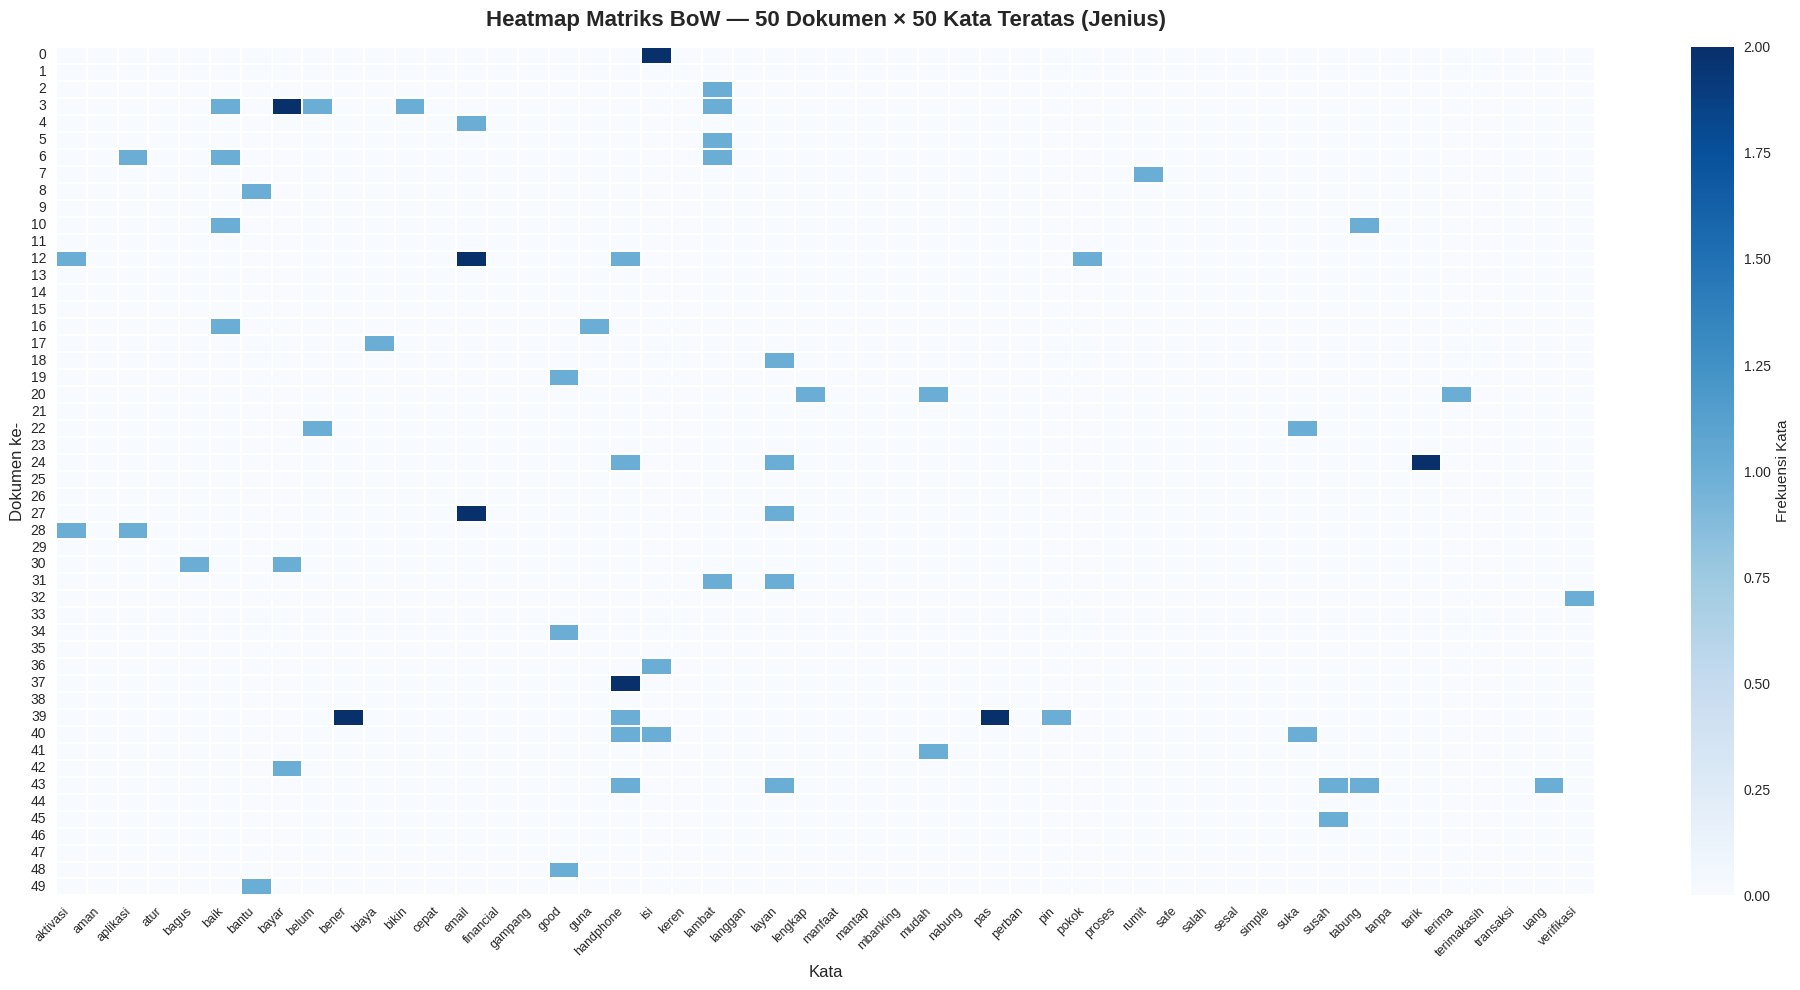

In [30]:
# Heatmap matriks BoW
plt.figure(figsize=(20, 10))
sns.heatmap(
    df_bow_matrix,
    cmap='Blues',
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'Frekuensi Kata'}
)
plt.title('Heatmap Matriks BoW — 50 Dokumen × 50 Kata Teratas (Jenius)',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Kata', fontsize=12)
plt.ylabel('Dokumen ke-', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

=== FREKUENSI TOTAL 50 KATA TERATAS ===


,Kata,Frekuensi
0,mudah,27974
1,bagus,14896
2,bantu,11200
3,tabung,9868
4,aplikasi,6704
5,cepat,6421
6,aktivasi,6352
7,rumit,6107
8,keren,5900
9,guna,4383


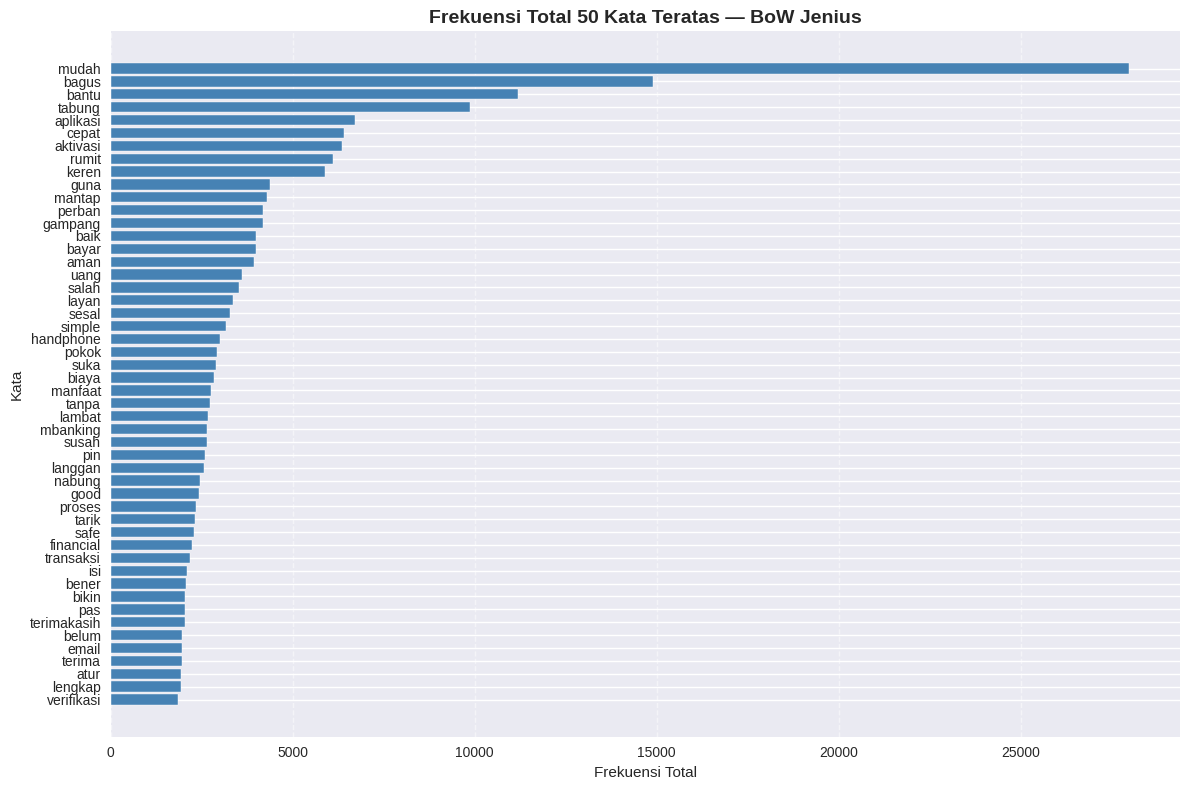

In [31]:
# Frekuensi total setiap kata dalam kosakata BoW
frekuensi_total = matriks_bow.toarray().sum(axis=0)
df_frekuensi = pd.DataFrame({
    'Kata'     : kosakata_50,
    'Frekuensi': frekuensi_total
}).sort_values('Frekuensi', ascending=False).reset_index(drop=True)

print('=== FREKUENSI TOTAL 50 KATA TERATAS ===')
display(df_frekuensi)

# Visualisasi
plt.figure(figsize=(12, 8))
plt.barh(df_frekuensi['Kata'][::-1], df_frekuensi['Frekuensi'][::-1],
         color='steelblue', edgecolor='white')
plt.title('Frekuensi Total 50 Kata Teratas — BoW Jenius',
          fontsize=14, fontweight='bold')
plt.xlabel('Frekuensi Total')
plt.ylabel('Kata')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

---
## 5. BoW Positif vs Negatif

Analisis BoW dilakukan secara terpisah pada kelompok ulasan **Positif** (skor 4–5) dan **Negatif** (skor 1–2) untuk mengekstraksi kata-kata yang paling dominan di masing-masing kelompok sentimen.

In [32]:
# Pisahkan dataset berdasarkan label
df_positif = df[df['label'] == 'Positif'].copy()
df_negatif = df[df['label'] == 'Negatif'].copy()

print(f'Jumlah ulasan Positif : {len(df_positif):,}')
print(f'Jumlah ulasan Negatif : {len(df_negatif):,}')

Jumlah ulasan Positif : 69,119
Jumlah ulasan Negatif : 23,500


In [33]:
# BoW untuk ulasan POSITIF
vec_positif  = CountVectorizer(max_features=50)
bow_positif  = vec_positif.fit_transform(df_positif['content_bersih'])
vocab_positif = vec_positif.get_feature_names_out()

freq_positif = bow_positif.toarray().sum(axis=0)
df_bow_pos   = pd.DataFrame({
    'Kata'     : vocab_positif,
    'Frekuensi': freq_positif
}).sort_values('Frekuensi', ascending=False).reset_index(drop=True)

print('=== TOP 50 KATA — ULASAN POSITIF ===')
display(df_bow_pos)

# BoW untuk ulasan NEGATIF
vec_negatif  = CountVectorizer(max_features=50)
bow_negatif  = vec_negatif.fit_transform(df_negatif['content_bersih'])
vocab_negatif = vec_negatif.get_feature_names_out()

freq_negatif = bow_negatif.toarray().sum(axis=0)
df_bow_neg   = pd.DataFrame({
    'Kata'     : vocab_negatif,
    'Frekuensi': freq_negatif
}).sort_values('Frekuensi', ascending=False).reset_index(drop=True)

print('=== TOP 50 KATA — ULASAN NEGATIF ===')
display(df_bow_neg)

=== TOP 50 KATA — ULASAN POSITIF ===


,Kata,Frekuensi
0,mudah,27457
1,bagus,13689
2,bantu,10441
3,tabung,9573
4,cepat,6046
5,keren,5851
6,aktivasi,5442
7,aplikasi,5313
8,rumit,4536
9,mantap,4225


=== TOP 50 KATA — ULASAN NEGATIF ===


,Kata,Frekuensi
0,salah,2168
1,pin,2029
2,layan,1973
3,susah,1854
4,lambat,1838
5,handphone,1720
6,email,1503
7,rumit,1485
8,pas,1343
9,langgan,1309


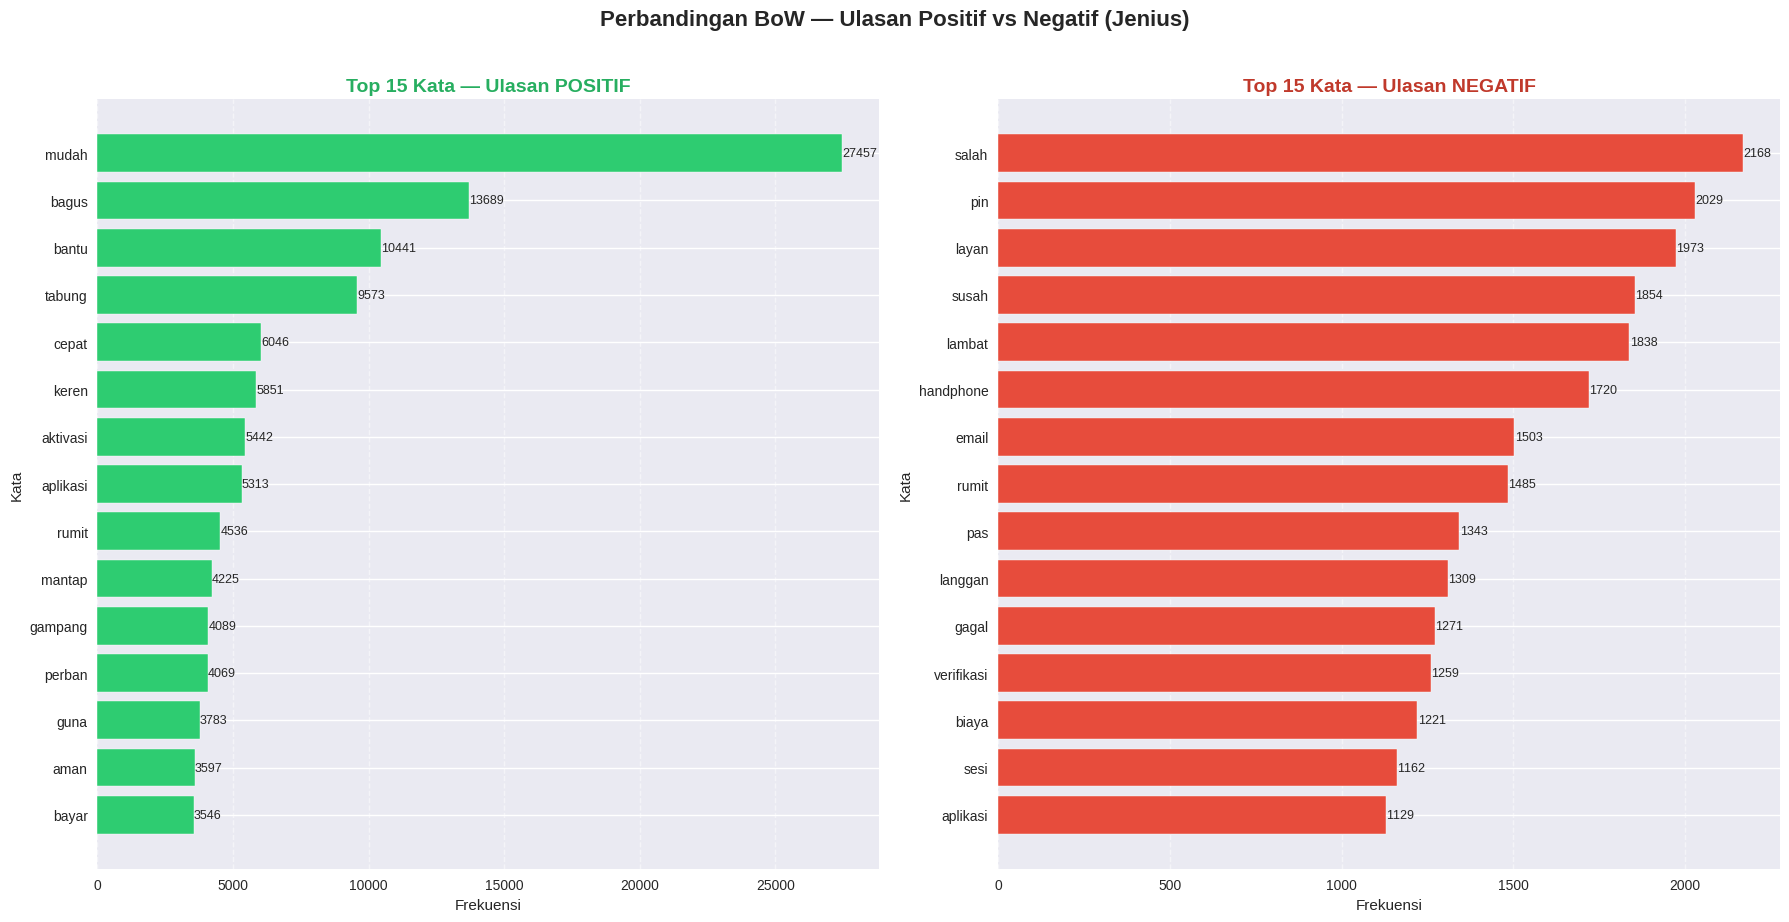

In [34]:
# Visualisasi perbandingan BoW Positif vs Negatif
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# Plot Positif
top15_pos = df_bow_pos.head(15)
axes[0].barh(top15_pos['Kata'][::-1], top15_pos['Frekuensi'][::-1],
             color='#2ecc71', edgecolor='white')
axes[0].set_title('Top 15 Kata — Ulasan POSITIF', fontsize=14, fontweight='bold', color='#27ae60')
axes[0].set_xlabel('Frekuensi')
axes[0].set_ylabel('Kata')
axes[0].grid(axis='x', linestyle='--', alpha=0.5)
for i, (kata, freq) in enumerate(zip(top15_pos['Kata'][::-1], top15_pos['Frekuensi'][::-1])):
    axes[0].text(freq + 1, i, str(freq), va='center', fontsize=9)

# Plot Negatif
top15_neg = df_bow_neg.head(15)
axes[1].barh(top15_neg['Kata'][::-1], top15_neg['Frekuensi'][::-1],
             color='#e74c3c', edgecolor='white')
axes[1].set_title('Top 15 Kata — Ulasan NEGATIF', fontsize=14, fontweight='bold', color='#c0392b')
axes[1].set_xlabel('Frekuensi')
axes[1].set_ylabel('Kata')
axes[1].grid(axis='x', linestyle='--', alpha=0.5)
for i, (kata, freq) in enumerate(zip(top15_neg['Kata'][::-1], top15_neg['Frekuensi'][::-1])):
    axes[1].text(freq + 1, i, str(freq), va='center', fontsize=9)

plt.suptitle('Perbandingan BoW — Ulasan Positif vs Negatif (Jenius)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

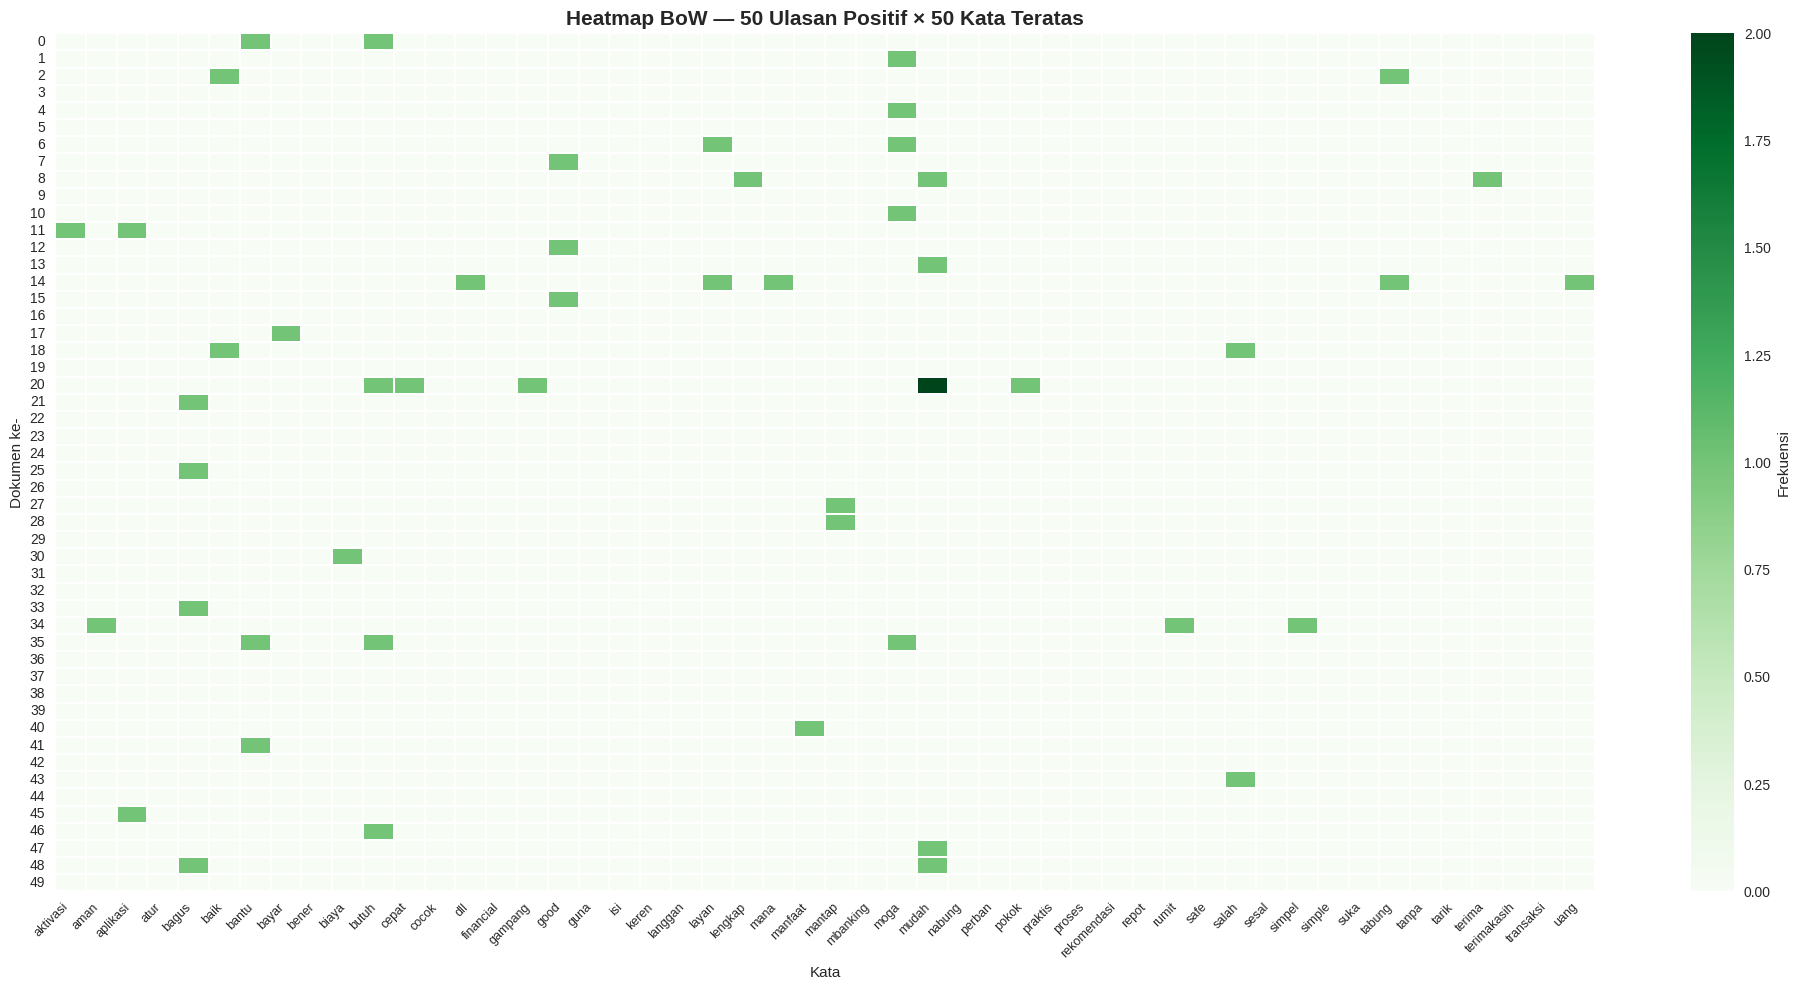

In [35]:
# Heatmap BoW 50 Dokumen Positif
df_bow_pos_matrix = pd.DataFrame(
    bow_positif[:50].toarray(),
    columns=vocab_positif
)
df_bow_pos_matrix.index.name = 'Dokumen Positif'

plt.figure(figsize=(20, 10))
sns.heatmap(df_bow_pos_matrix, cmap='Greens', linewidths=0.3,
            linecolor='white', cbar_kws={'label': 'Frekuensi'})
plt.title('Heatmap BoW — 50 Ulasan Positif × 50 Kata Teratas',
          fontsize=15, fontweight='bold')
plt.xlabel('Kata')
plt.ylabel('Dokumen ke-')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

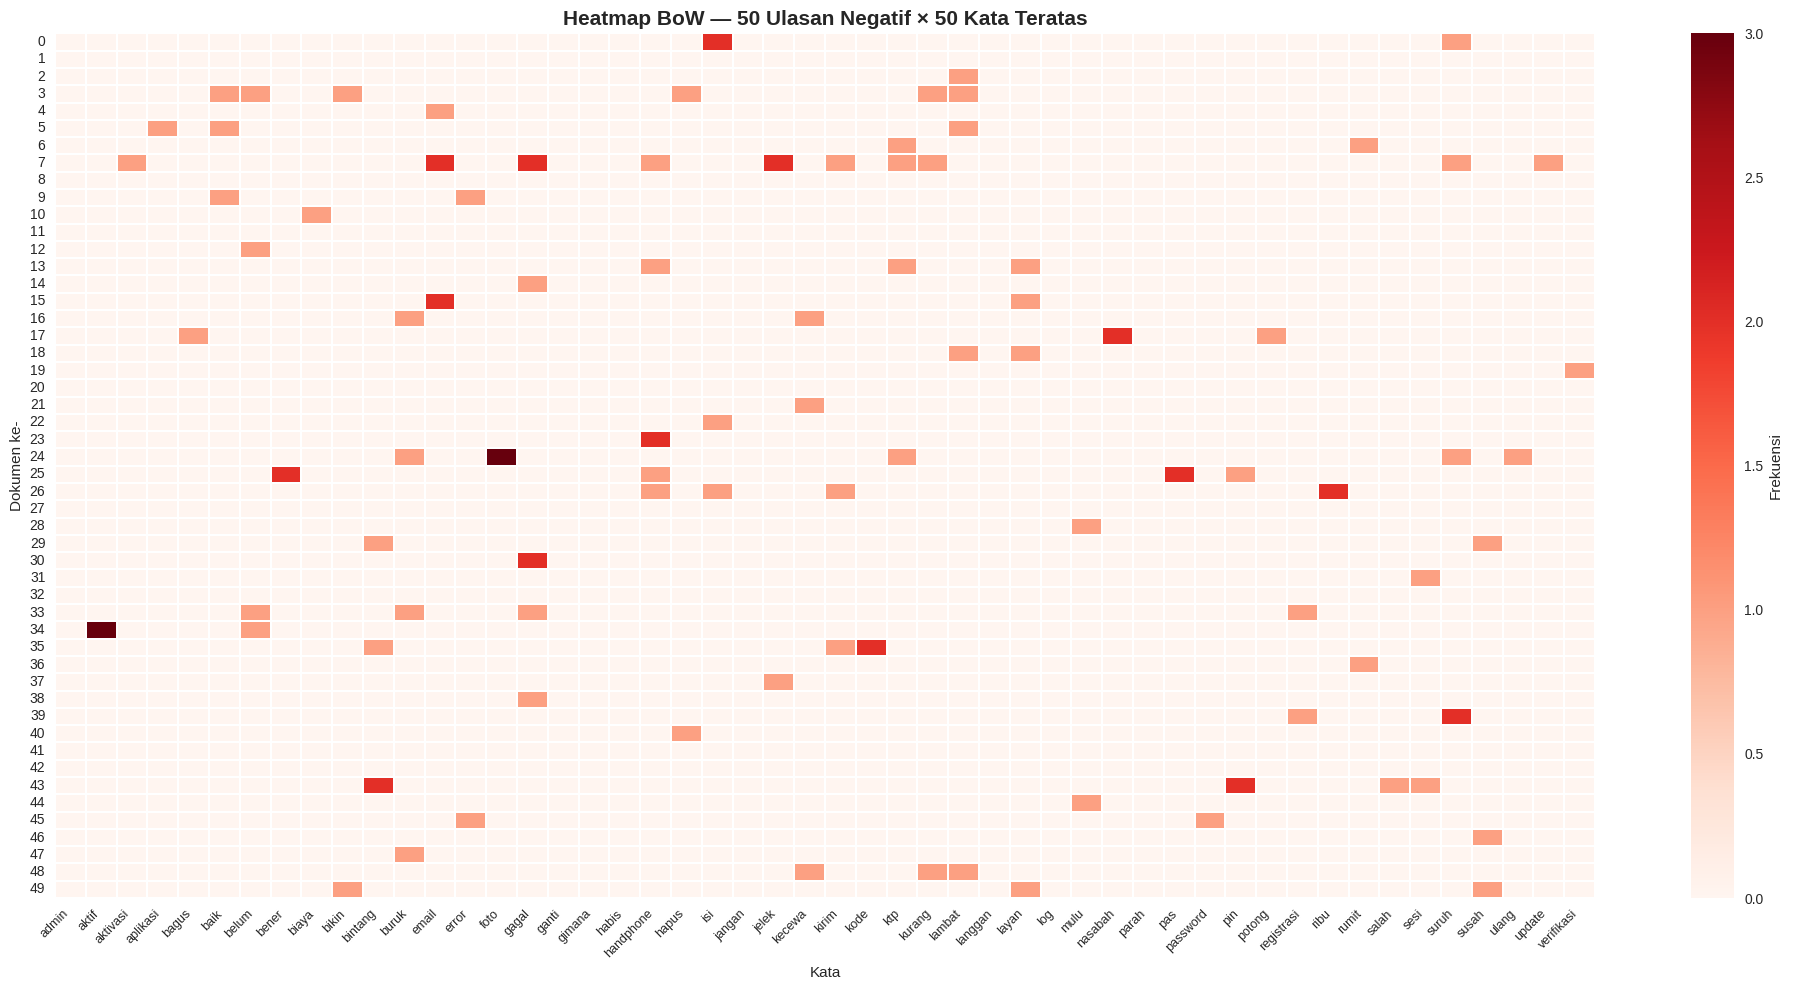

In [36]:
# Heatmap BoW 50 Dokumen Negatif
df_bow_neg_matrix = pd.DataFrame(
    bow_negatif[:50].toarray(),
    columns=vocab_negatif
)
df_bow_neg_matrix.index.name = 'Dokumen Negatif'

plt.figure(figsize=(20, 10))
sns.heatmap(df_bow_neg_matrix, cmap='Reds', linewidths=0.3,
            linecolor='white', cbar_kws={'label': 'Frekuensi'})
plt.title('Heatmap BoW — 50 Ulasan Negatif × 50 Kata Teratas',
          fontsize=15, fontweight='bold')
plt.xlabel('Kata')
plt.ylabel('Dokumen ke-')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

## 6. Analisis Regex — Ekstraksi Insight

Analisis Regex digunakan untuk mengekstraksi pola teks spesifik yang sering muncul pada ulasan, seperti keluhan fitur, masalah teknis, dan pujian pengguna.

In [37]:
pola_regex = {
    # ── Keluhan Teknis ──────────────────────────────────────────
    'Masalah Login / Verifikasi':
        r'(?:tidak bisa|gagal|error|susah|masalah|kendala)\s+(?:login|masuk|verifikasi|daftar)'
        r'|(?:kode otp|otp tidak|otp gagal)'
        r'|(?:akun.*?terkunci|akun.*?diblokir)',

    'Aplikasi Lambat / Crash':
        r'(?:lambat|lemot|lelet|loading|hang|crash|force close|berhenti|not responding|berat|keluar sendiri|sering keluar)',

    'Transfer Gagal / Bermasalah':
        r'transfer\s+(?:gagal|error|tidak berhasil|tidak masuk|tertunda|pending)'
        r'|(?:gagal|error)\s+(?:transfer|kirim)'
        r'|kirim\s+uang\s+(?:gagal|tidak masuk)',

    'Saldo Tidak Sesuai':
        r'saldo\s+(?:hilang|berkurang|tidak masuk|tidak sesuai|salah|raib|terpotong)'
        r'|uang\s+(?:hilang|raib|berkurang|tidak kembali)'
        r'|(?:terpotong|dipotong)\s+(?:tanpa|tidak)',

    'Customer Service Buruk':
        r'(?:cs|customer service|layanan|admin|pelayan)\s+(?:tidak responsif|lambat|tidak membantu|buruk|jelek|parah)'
        r'|(?:tidak ada|susah)\s+(?:respon|balasan|jawaban)'
        r'|(?:dihubungi|menghubungi).*?(?:tidak|susah|lama)',

    # ── Pujian Pengguna ─────────────────────────────────────────

    'Mudah Digunakan':
        r'(?:mudah|gampang|praktis|simpel|simple|user friendly|intuitif|memudahkan)',

    'Fitur Lengkap':
        r'(?:fitur|fungsi)\s+(?:lengkap|canggih|bagus|keren|mantap|oke)'
        r'|fitur\s+(?:nya\s+)?(?:banyak|komplit)',

    'Transaksi Cepat':
        r'(?:transfer|transaksi|bayar|pembayaran)\s+(?:cepat|instan|langsung|segera)'
        r'|(?:cepat|instan)\s+(?:transfer|transaksi)',

    'Keamanan Terjaga':
        r'(?:sangat|cukup|merasa)\s+aman'
        r'|(?:keamanan|keamanannya)\s+(?:bagus|baik|terjaga|terjamin)'
        r'|(?:aman|secure|terpercaya)\s+(?:digunakan|banget|sekali)',

    'Promo / Cashback Menarik':
        r'(?:promo|cashback|diskon|bonus|reward|hadiah)\s+(?:menarik|bagus|banyak|sering)'
        r'|(?:dapat|ada|banyak)\s+(?:promo|cashback|diskon)',
}

In [19]:
# ── Terapkan pola Regex ke seluruh dataset ──────────────────────
for nama_pola, ekspresi in pola_regex.items():
    df[nama_pola] = df['content'].str.lower().str.contains(
        ekspresi, regex=True, na=False
    )

# Hitung total kemunculan setiap pola
hasil_regex = pd.DataFrame({
    'Kategori'         : list(pola_regex.keys()),
    'Total Kemunculan' : [df[nama].sum() for nama in pola_regex.keys()],
    'Tipe'             : [
        'Keluhan','Keluhan','Keluhan','Keluhan','Keluhan',
        'Pujian','Pujian','Pujian','Pujian','Pujian'
    ]
}).sort_values('Total Kemunculan', ascending=False).reset_index(drop=True)

print('=== HASIL ANALISIS REGEX ===')
display(hasil_regex)

=== HASIL ANALISIS REGEX ===


,Kategori,Total Kemunculan,Tipe
0,Mudah Digunakan,26757,Pujian
1,Keamanan Terjaga,7401,Pujian
2,Aplikasi Lambat / Crash,3428,Keluhan
3,Promo / Cashback Menarik,1447,Pujian
4,Masalah Login / Verifikasi,1289,Keluhan
5,Fitur Lengkap,164,Pujian
6,Transaksi Cepat,138,Pujian
7,Saldo Tidak Sesuai,64,Keluhan
8,Customer Service Buruk,59,Keluhan
9,Transfer Gagal / Bermasalah,20,Keluhan


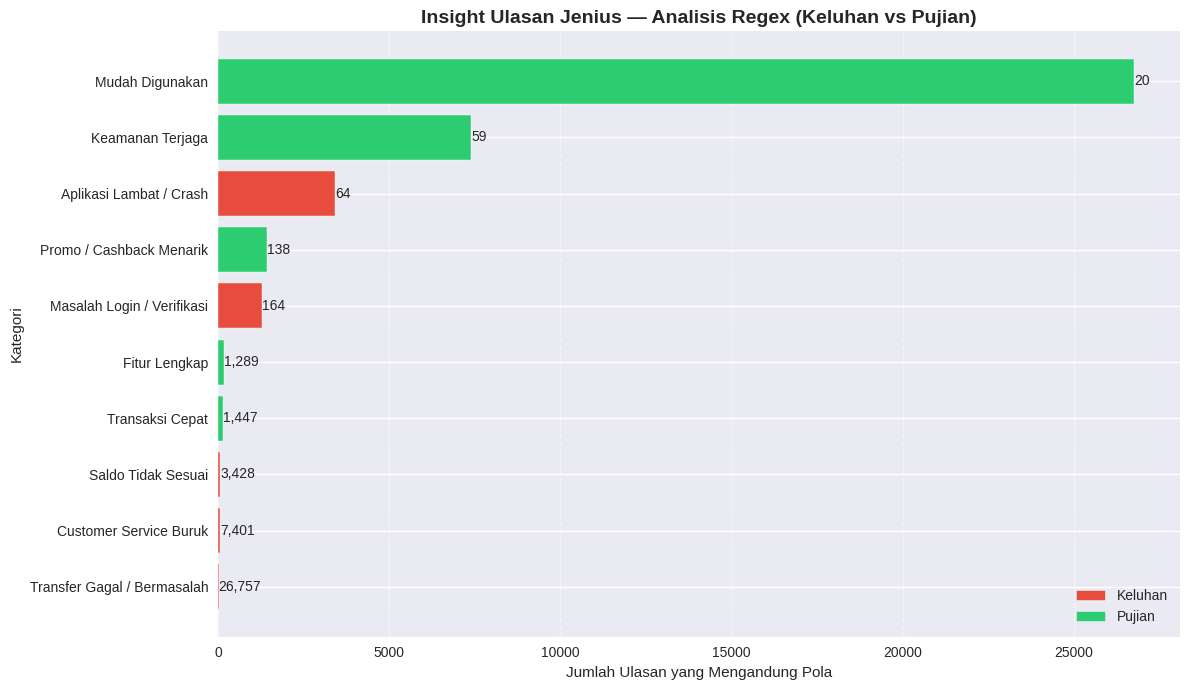

In [38]:
# Visualisasi hasil Regex
warna_map = {'Keluhan': '#e74c3c', 'Pujian': '#2ecc71'}
warna_bar = [warna_map[t] for t in hasil_regex['Tipe']]

plt.figure(figsize=(12, 7))
bars = plt.barh(
    hasil_regex['Kategori'][::-1],
    hasil_regex['Total Kemunculan'][::-1],
    color=warna_bar[::-1], edgecolor='white'
)
plt.title('Insight Ulasan Jenius — Analisis Regex (Keluhan vs Pujian)',
          fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Ulasan yang Mengandung Pola')
plt.ylabel('Kategori')
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Label nilai
for bar, val in zip(bars[::-1], hasil_regex['Total Kemunculan'][::-1]):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=10)

# Legend manual
from matplotlib.patches import Patch
legend = [Patch(color='#e74c3c', label='Keluhan'),
          Patch(color='#2ecc71', label='Pujian')]
plt.legend(handles=legend, loc='lower right')
plt.tight_layout()
plt.show()

In [39]:
# ── Contoh ulasan per kategori Regex ───────────────────────────
print('=' * 60)
for nama_pola in pola_regex.keys():
    contoh = df[df[nama_pola] == True]['content'].head(3).tolist()
    print(f'\n📌 {nama_pola} ({df[nama_pola].sum()} ulasan)')
    print('-' * 50)
    for i, ulasan in enumerate(contoh, 1):
        print(f'  {i}. {ulasan[:150]}...' if len(ulasan) > 150 else f'  {i}. {ulasan}')


📌 Masalah Login / Verifikasi (1205 ulasan)
--------------------------------------------------
  1. buruk saya baru saja daftar dan coba top up namun sudah tidak bisa masuk ke akun jenius saya sangan kecewa
  2. kenapa saya tidak bisa masuk saat login keluar lagi, maksudnya apa ini saldo saya mau di curi gitu, coba jika memang aplikasi ini amanah, mohon bantua...
  3. perangkat lama saya suda tidak aktip saya tidak bisa masuk perangkat baru

📌 Aplikasi Lambat / Crash (3428 ulasan)
--------------------------------------------------
  1. mobile banking paling berat dan lambat yang pernah saya pakai. Tolong diupgrade.
  2. tolong perbaiki sistemnya ya, kita sudah berusaha untuk selalu tepat waktu namun sistem selalu membaca terlambat, dan akhirnya terbaca kredibilitas ki...
  3. loading nya agak lambat ketika mau buka aplikasi & ketika sesduah transfer bukti nya lama kluar nya.

📌 Transfer Gagal / Bermasalah (20 ulasan)
--------------------------------------------------
  1. Transfer gaga

## 7. Analisis Lanjutan — Regex per Sentimen

In [40]:
# Distribusi pola Regex pada ulasan Positif vs Negatif
hasil_per_label = {}
for nama_pola in pola_regex.keys():
    hasil_per_label[nama_pola] = {
        'Positif': df[(df[nama_pola]) & (df['label'] == 'Positif')].shape[0],
        'Negatif': df[(df[nama_pola]) & (df['label'] == 'Negatif')].shape[0],
    }

df_per_label = pd.DataFrame(hasil_per_label).T.reset_index()
df_per_label.columns = ['Kategori', 'Positif', 'Negatif']

print('=== DISTRIBUSI POLA REGEX PER LABEL SENTIMEN ===')
display(df_per_label)

=== DISTRIBUSI POLA REGEX PER LABEL SENTIMEN ===


,Kategori,Positif,Negatif
0,Masalah Login / Verifikasi,192,861
1,Aplikasi Lambat / Crash,717,2289
2,Transfer Gagal / Bermasalah,0,19
3,Saldo Tidak Sesuai,6,55
4,Customer Service Buruk,2,57
5,Mudah Digunakan,26086,535
6,Fitur Lengkap,154,7
7,Transaksi Cepat,121,10
8,Keamanan Terjaga,6162,1082
9,Promo / Cashback Menarik,906,442


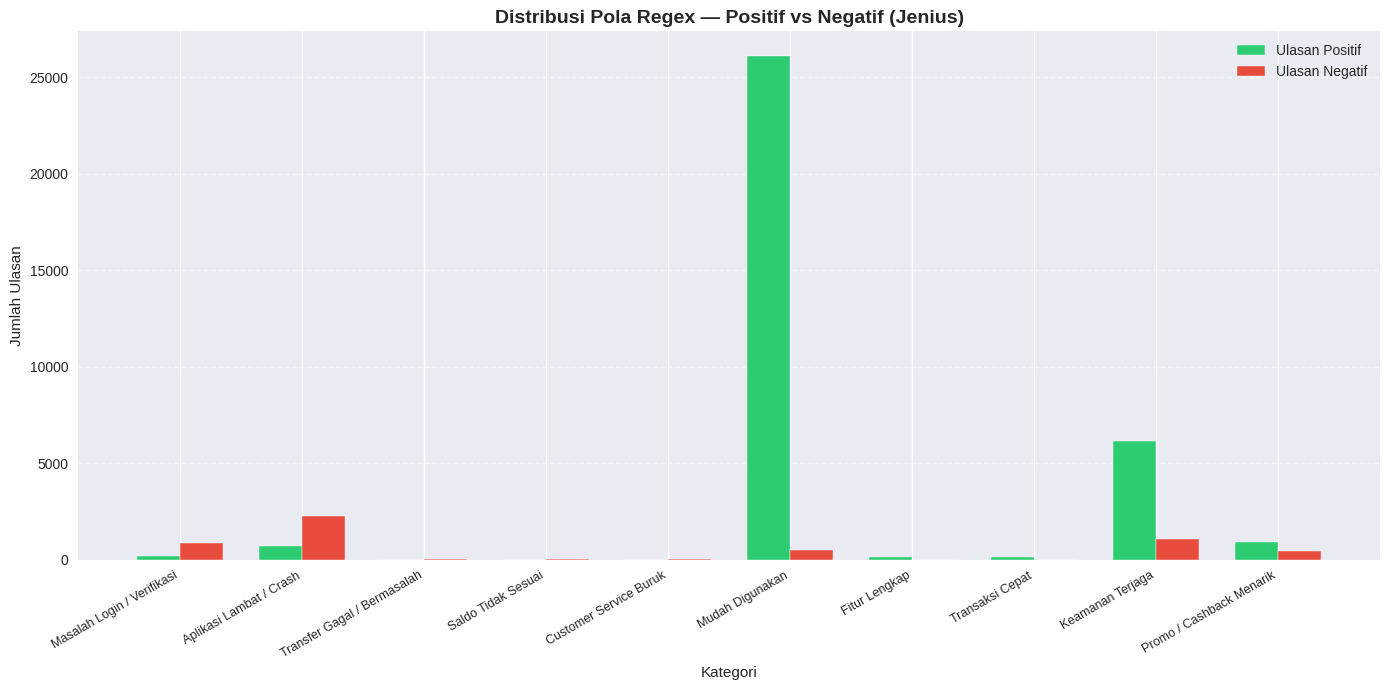

In [41]:
# Grouped bar chart Regex per sentimen
x = np.arange(len(df_per_label))
lebar = 0.35

fig, ax = plt.subplots(figsize=(14, 7))
bar1 = ax.bar(x - lebar/2, df_per_label['Positif'], lebar,
              label='Ulasan Positif', color='#2ecc71', edgecolor='white')
bar2 = ax.bar(x + lebar/2, df_per_label['Negatif'], lebar,
              label='Ulasan Negatif', color='#e74c3c', edgecolor='white')

ax.set_title('Distribusi Pola Regex — Positif vs Negatif (Jenius)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Kategori')
ax.set_ylabel('Jumlah Ulasan')
ax.set_xticks(x)
ax.set_xticklabels(df_per_label['Kategori'], rotation=30, ha='right', fontsize=9)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 8. Ringkasan & Kesimpulan

In [42]:
# Ringkasan statistik
print('=' * 60)
print('         RINGKASAN ANALISIS BoW & REGEX — JENIUS')
print('=' * 60)
print(f'Total ulasan dianalisis  : {len(df):,}')
print(f'Ulasan Positif           : {len(df_positif):,} ({len(df_positif)/len(df)*100:.1f}%)')
print(f'Ulasan Negatif           : {len(df_negatif):,} ({len(df_negatif)/len(df)*100:.1f}%)')
print(f'Ukuran kosakata BoW      : 50 kata teratas')
print(f'Pola Regex diterapkan    : {len(pola_regex)} kategori')

print('\n--- TOP 5 KATA POSITIF ---')
for _, row in df_bow_pos.head(5).iterrows():
    print(f'  {row["Kata"]:<20} {row["Frekuensi"]:,}x')

print('\n--- TOP 5 KATA NEGATIF ---')
for _, row in df_bow_neg.head(5).iterrows():
    print(f'  {row["Kata"]:<20} {row["Frekuensi"]:,}x')

print('\n--- KELUHAN TERBANYAK ---')
keluhan = hasil_regex[hasil_regex['Tipe'] == 'Keluhan'].head(3)
for _, row in keluhan.iterrows():
    print(f'  {row["Kategori"]:<35} {row["Total Kemunculan"]:,} ulasan')

print('\n--- PUJIAN TERBANYAK ---')
pujian = hasil_regex[hasil_regex['Tipe'] == 'Pujian'].head(3)
for _, row in pujian.iterrows():
    print(f'  {row["Kategori"]:<35} {row["Total Kemunculan"]:,} ulasan')
print('=' * 60)

         RINGKASAN ANALISIS BoW & REGEX — JENIUS
Total ulasan dianalisis  : 97,258
Ulasan Positif           : 69,119 (71.1%)
Ulasan Negatif           : 23,500 (24.2%)
Ukuran kosakata BoW      : 50 kata teratas
Pola Regex diterapkan    : 10 kategori

--- TOP 5 KATA POSITIF ---
  mudah                27,457x
  bagus                13,689x
  bantu                10,441x
  tabung               9,573x
  cepat                6,046x

--- TOP 5 KATA NEGATIF ---
  salah                2,168x
  pin                  2,029x
  layan                1,973x
  susah                1,854x
  lambat               1,838x

--- KELUHAN TERBANYAK ---
  Aplikasi Lambat / Crash             3,428 ulasan
  Masalah Login / Verifikasi          1,289 ulasan
  Saldo Tidak Sesuai                  64 ulasan

--- PUJIAN TERBANYAK ---
  Mudah Digunakan                     26,757 ulasan
  Keamanan Terjaga                    7,401 ulasan
  Promo / Cashback Menarik            1,447 ulasan


In [ ]:
# ── Simpan hasil analisis ───────────────────────────────────────
df_bow_pos.to_csv('bow_positif_jenius.csv', index=False, encoding='utf-8')
df_bow_neg.to_csv('bow_negatif_jenius.csv', index=False, encoding='utf-8')
hasil_regex.to_csv('regex_insight_jenius.csv', index=False, encoding='utf-8')

print('✅ File berhasil disimpan:')
print('   - bow_positif_jenius.csv')
print('   - bow_negatif_jenius.csv')
print('   - regex_insight_jenius.csv')